# Phase 1 — 跨期 Transition Matrix 分析

**假說（D-revised）**：上期出現的號碼，會影響下期號碼的出現機率。

**方法**：
- 建 38×38 transition matrix T：T[x][y] = 上期含 x 且下期含 y 的期數
- **Test B**（row-level）：χ² 檢定每個 x 的 T[x,:] 是否均勻 → 有顯著 row = 有候選訊號
- **Test A**（cell-level）：Binomial test 每個 (x,y) + FDR (BH) q < 0.05 → 找顯著 transition
- **結案條件**：Test B 全無顯著（p > 0.05）→ 無跨期訊號，結案

**資料**：訓練集 1,807 期（Holdout 100 期鎖死，Phase 2 才解封）

## 1. 載入資料 & 建相鄰期對

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Microsoft JhengHei",
    "axes.unicode_minus": False,
})

DB = Path("lottery.db")
conn = sqlite3.connect(DB)
df = pd.read_sql(
    "SELECT id, draw_id, draw_date, n1,n2,n3,n4,n5,n6, n_zone2 "
    "FROM draws WHERE split='train' ORDER BY id",
    conn,
)
conn.close()

Z1 = ["n1","n2","n3","n4","n5","n6"]
N = len(df)
print(f"訓練期數：{N}")
print(f"相鄰期對數：{N-1}（lag-1）")

# 每期的號碼集合（方便查找）
draws_z1 = [set(row) for row in df[Z1].itertuples(index=False, name=None)]
draws_z2 = list(df["n_zone2"])
df.head(3)

訓練期數：1807
相鄰期對數：1806（lag-1）


,id,draw_id,draw_date,n1,n2,n3,n4,n5,n6,n_zone2
0,1,97000001,2008/01/24,3,4,16,18,36,37,2
1,2,97000002,2008/01/28,2,14,15,16,28,29,8
2,3,97000003,2008/01/31,6,9,11,13,19,23,2


## 2. 建 Transition Matrix

In [2]:
# 一區 38×38
T_z1 = np.zeros((39, 39), dtype=int)   # index 1-38，0 不用
for t in range(N - 1):
    for x in draws_z1[t]:
        for y in draws_z1[t + 1]:
            T_z1[x, y] += 1

# 二區 8×8
T_z2 = np.zeros((9, 9), dtype=int)     # index 1-8
for t in range(N - 1):
    x = draws_z2[t]
    y = draws_z2[t + 1]
    T_z2[x, y] += 1

# ── 完整性檢查 ──
# 每個 x 出現次數 = df 中 n1~n6 含 x 的期數（前 N-1 期）
freq_z1 = np.zeros(39, dtype=int)
for s in draws_z1[:-1]:   # 前 N-1 期（作為「上期」）
    for x in s:
        freq_z1[x] += 1

row_sums = T_z1[1:, 1:].sum(axis=1)   # T[x,:] 總和
expected_row_sums = freq_z1[1:] * 6

assert np.allclose(row_sums, expected_row_sums), "row sum 不符合 freq×6"
print("✅ T_z1 row sum 驗證通過：每個 x 的 row 總和 == freq(x) × 6")
print(f"T_z1 shape: {T_z1.shape}，總計數: {T_z1[1:,1:].sum():,}")

col_sums = T_z2[1:, 1:].sum(axis=1)
freq_z2_src = np.zeros(9, dtype=int)
for x in draws_z2[:-1]:
    freq_z2_src[x] += 1
assert np.allclose(col_sums, freq_z2_src[1:]), "二區 row sum 不符"
print(f"✅ T_z2 row sum 驗證通過")
print(f"T_z2 shape: {T_z2.shape}，總計數: {T_z2[1:,1:].sum():,}")

✅ T_z1 row sum 驗證通過：每個 x 的 row 總和 == freq(x) × 6
T_z1 shape: (39, 39)，總計數: 65,016
✅ T_z2 row sum 驗證通過
T_z2 shape: (9, 9)，總計數: 1,806


## 3. Test B — Row-level χ² 檢定（一區）

對每個號碼 x：在 x 出現後的下一期，38 個號碼的出現次數是否均勻？

H₀：T[x, 1:39] 均勻分布（每個 y 期望值 = row_sum / 38）

In [3]:
testB_results = []
for x in range(1, 39):
    row = T_z1[x, 1:39]          # counts for y=1..38
    row_total = row.sum()
    if row_total == 0:
        continue
    expected = np.full(38, row_total / 38)
    chi2, p = stats.chisquare(row, f_exp=expected)
    testB_results.append({"x": x, "chi2": chi2, "p": p, "n_obs": row_total})

testB_df = pd.DataFrame(testB_results).set_index("x")

# 原始 p < 0.05 的號碼
sig_B_raw = testB_df[testB_df["p"] < 0.05]
print(f"Test B：{len(testB_df)} 個號碼檢定完畢")
print(f"原始 p < 0.05：{len(sig_B_raw)} 個（隨機期望約 {38*0.05:.1f} 個）")
print()

# Bonferroni 校正（較嚴格，先看）
bonf_threshold = 0.05 / 38
sig_B_bonf = testB_df[testB_df["p"] < bonf_threshold]
print(f"Bonferroni 校正後顯著（p < {bonf_threshold:.4f}）：{len(sig_B_bonf)} 個")

# FDR (BH) 校正
_, q_vals, _, _ = multipletests(testB_df["p"].values, method="fdr_bh")
testB_df["q_bh"] = q_vals
sig_B_fdr = testB_df[testB_df["q_bh"] < 0.05]
print(f"FDR (BH) q < 0.05：{len(sig_B_fdr)} 個")

print()
print(testB_df.sort_values("p").head(10).round(4))

Test B：38 個號碼檢定完畢
原始 p < 0.05：0 個（隨機期望約 1.9 個）

Bonferroni 校正後顯著（p < 0.0013）：0 個
FDR (BH) q < 0.05：0 個

       chi2       p  n_obs    q_bh
x                                 
29  43.7379  0.2071   1770  0.9893
27  43.6432  0.2099   1704  0.9893
7   39.3986  0.3631   1776  0.9893
14  37.9553  0.4256   1788  0.9893
2   37.4557  0.4482   1602  0.9893
9   37.4083  0.4503   1440  0.9893
30  36.7052  0.4827   1662  0.9893
11  36.0167  0.5150   1680  0.9893
36  35.1244  0.5572   1704  0.9893
20  35.0439  0.5610   1686  0.9893


C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_14684\4032050647.py:21: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_14684\4032050647.py:21: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


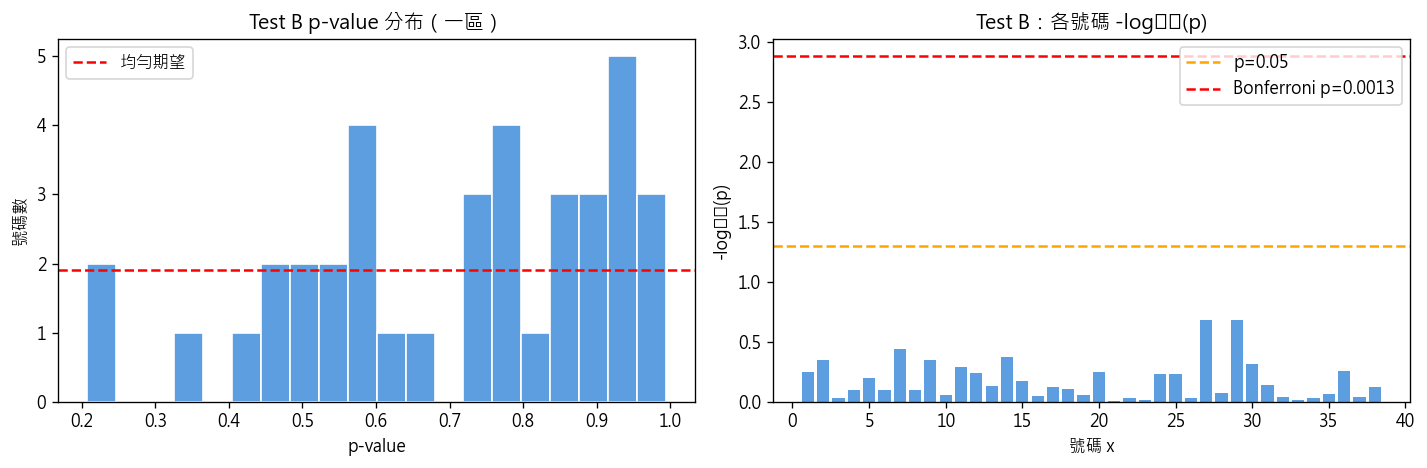

In [4]:
# p-value 分布圖（若 H₀ 成立，應均勻分布）
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(testB_df["p"], bins=20, color="#5c9ee0", edgecolor="white")
axes[0].axhline(len(testB_df) / 20, color="red", linestyle="--", label="均勻期望")
axes[0].set_title("Test B p-value 分布（一區）")
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("號碼數")
axes[0].legend()

# 各號碼的 -log10(p)
axes[1].bar(testB_df.index, -np.log10(testB_df["p"]), color="#5c9ee0")
axes[1].axhline(-np.log10(0.05), color="orange", linestyle="--", label="p=0.05")
axes[1].axhline(-np.log10(bonf_threshold), color="red", linestyle="--",
                label=f"Bonferroni p={bonf_threshold:.4f}")
axes[1].set_title("Test B：各號碼 -log₁₀(p)")
axes[1].set_xlabel("號碼 x")
axes[1].set_ylabel("-log₁₀(p)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Test A — Cell-level Binomial 檢定 + FDR（一區）

對每個 (x, y)：給定上期含 x，下期含 y 的機率是否顯著偏離 H₀ = 6/38？

- 試驗次數 n = freq(x)（x 出現的總期數）
- 成功次數 k = T[x][y]
- H₀ p = 6/38（若獨立，每期下一期含 y 的機率）
- 共 38×38 = 1,444 個檢定，FDR (BH) q < 0.05

In [5]:
p0 = 6 / 38   # H₀ 成功機率

testA_records = []
for x in range(1, 39):
    n_x = freq_z1[x]
    if n_x == 0:
        continue
    for y in range(1, 39):
        k = T_z1[x, y]
        result = stats.binomtest(k, n=n_x, p=p0, alternative="two-sided")
        obs_rate = k / n_x
        testA_records.append({
            "x": x, "y": y,
            "k": k, "n": n_x,
            "obs_rate": obs_rate,
            "p_raw": result.pvalue,
        })

testA_df = pd.DataFrame(testA_records)

# FDR (BH) 校正
_, q_vals, _, _ = multipletests(testA_df["p_raw"].values, method="fdr_bh")
testA_df["q_bh"] = q_vals
testA_df["lift"] = testA_df["obs_rate"] / p0

sig_A = testA_df[testA_df["q_bh"] < 0.05].copy()
print(f"Test A：{len(testA_df)} 個 cell 檢定完畢")
print(f"FDR q < 0.05：{len(sig_A)} 個顯著 cell（隨機期望 ≈ {len(testA_df)*0.05:.0f}）")
print()

if len(sig_A) > 0:
    print("顯著 cell（排序 by lift 遞減）：")
    print(sig_A.sort_values("lift", ascending=False)[
        ["x","y","k","n","obs_rate","lift","q_bh"]
    ].head(20).round(4).to_string())
else:
    print("→ 無顯著 cell，Test A 無訊號")

Test A：1444 個 cell 檢定完畢
FDR q < 0.05：0 個顯著 cell（隨機期望 ≈ 72）

→ 無顯著 cell，Test A 無訊號


## 5. 視覺化 — Transition Heatmap & 顯著 Row Barplot

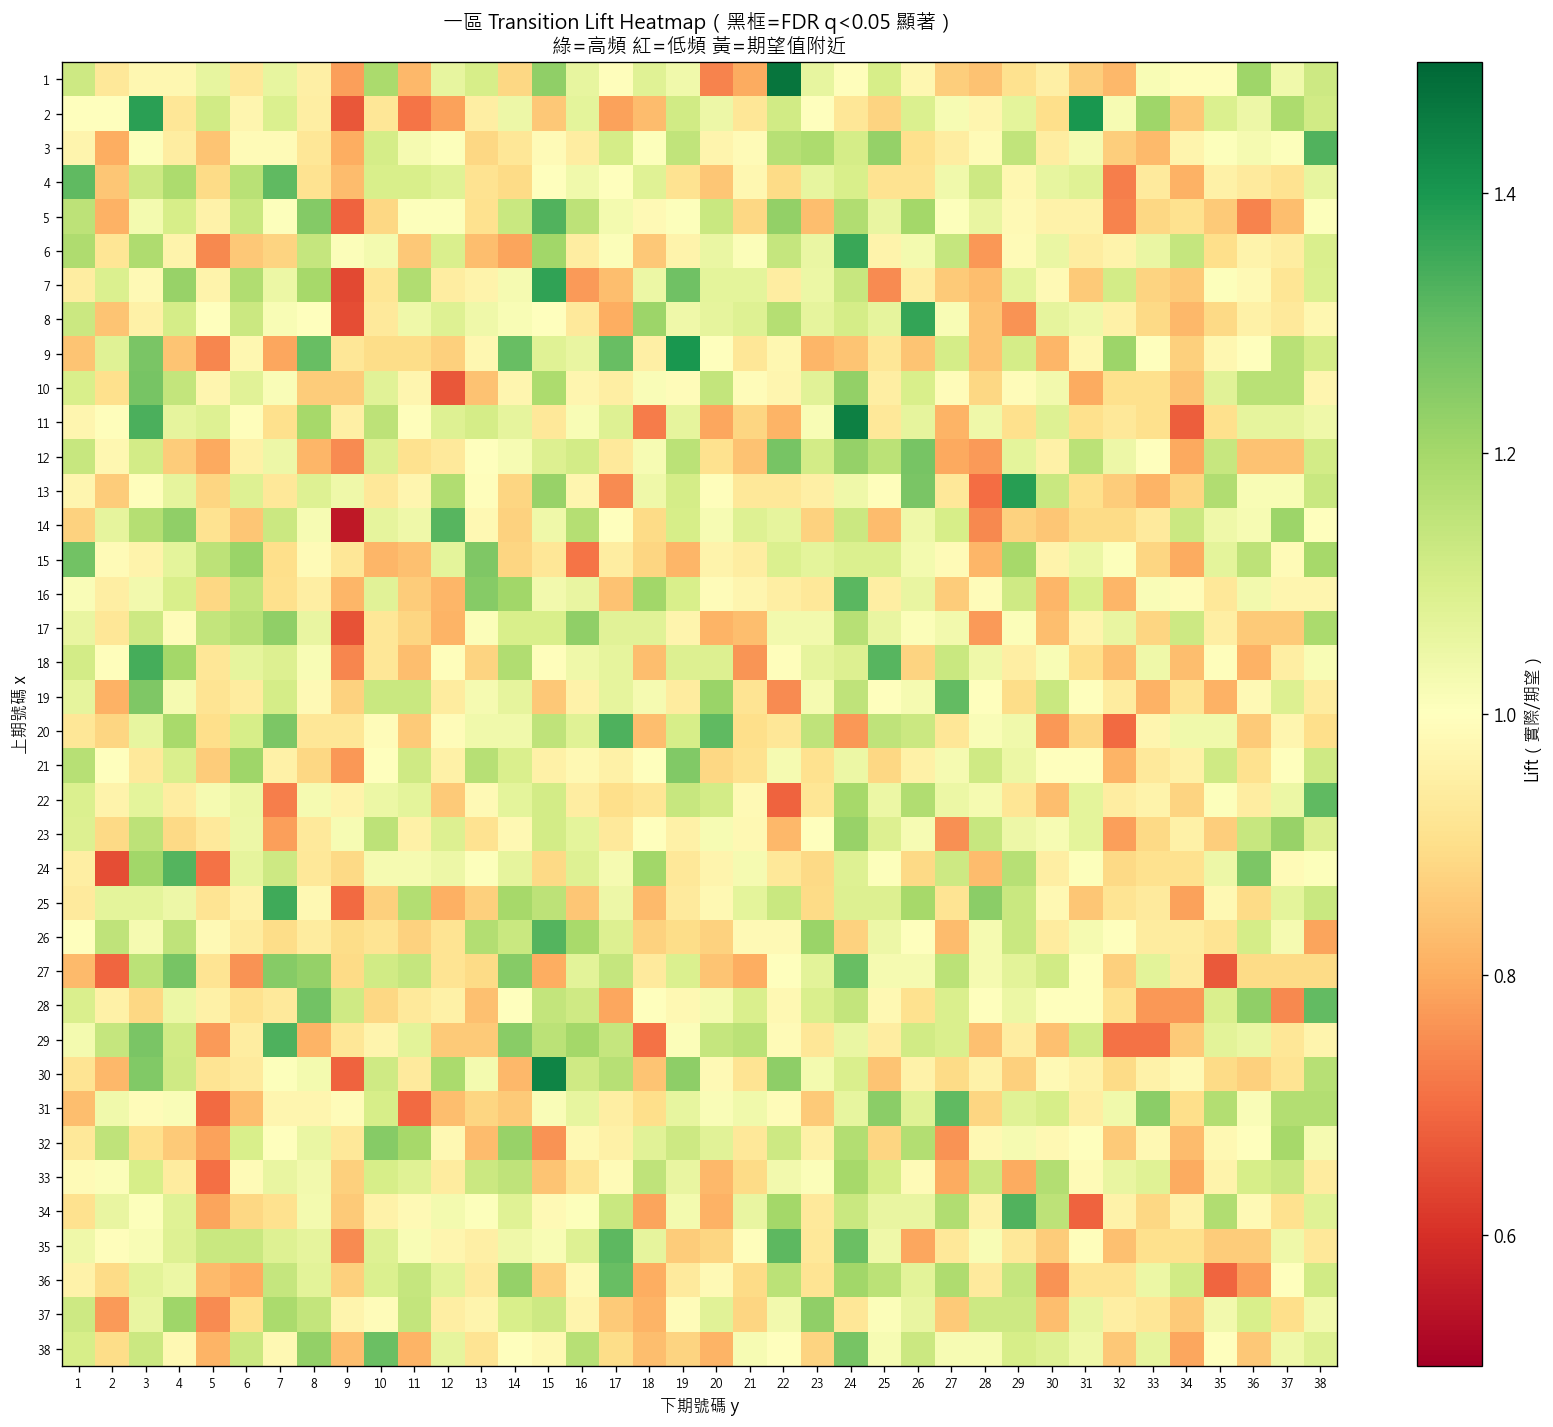

In [6]:
# ── 5a. Lift heatmap（一區）──
lift_mat = np.full((38, 38), np.nan)
for _, row in testA_df.iterrows():
    lift_mat[int(row.x)-1, int(row.y)-1] = row.lift

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(lift_mat, cmap="RdYlGn", vmin=0.5, vmax=1.5, aspect="auto")
plt.colorbar(im, ax=ax, label="Lift（實際/期望）")

# 標出 FDR 顯著 cell
if len(sig_A) > 0:
    for _, row in sig_A.iterrows():
        ax.add_patch(plt.Rectangle(
            (row.y - 1.5, row.x - 1.5), 1, 1,
            fill=False, edgecolor="black", linewidth=1.5
        ))

ax.set_xticks(range(38))
ax.set_xticklabels(range(1, 39), fontsize=7)
ax.set_yticks(range(38))
ax.set_yticklabels(range(1, 39), fontsize=7)
ax.set_xlabel("下期號碼 y")
ax.set_ylabel("上期號碼 x")
ax.set_title("一區 Transition Lift Heatmap（黑框=FDR q<0.05 顯著）\n綠=高頻 紅=低頻 黃=期望值附近")
plt.tight_layout()
plt.show()

In [7]:
# ── 5b. Test B 顯著 row 的詳細 barplot ──
sig_B_rows = testB_df[testB_df["p"] < 0.05].index.tolist()

if not sig_B_rows:
    print("Test B：無原始顯著 row，略過 barplot")
else:
    n_sig = len(sig_B_rows)
    fig, axes = plt.subplots(n_sig, 1, figsize=(14, 4 * n_sig))
    if n_sig == 1:
        axes = [axes]

    for ax, x in zip(axes, sig_B_rows):
        row = T_z1[x, 1:39]
        expected_val = row.sum() / 38
        colors = ["#e05c5c" if v > expected_val * 1.1 else
                  "#5c9ee0" if v < expected_val * 0.9 else "#aaaaaa"
                  for v in row]
        ax.bar(range(1, 39), row, color=colors, width=0.7)
        ax.axhline(expected_val, color="black", linestyle="--",
                   linewidth=1, label=f"期望 {expected_val:.1f}")
        p_val = testB_df.loc[x, "p"]
        q_val = testB_df.loc[x, "q_bh"]
        ax.set_title(f"號碼 {x} 出現後，下期分布  (p={p_val:.4f}, q_BH={q_val:.4f})")
        ax.set_xlabel("下期號碼 y")
        ax.set_ylabel("次數")
        ax.set_xticks(range(1, 39))
        ax.legend()

    plt.tight_layout()
    plt.show()

Test B：無原始顯著 row，略過 barplot


## 6. 二區 Transition（8×8）

=== 二區 Test B（8 個號碼）===
     chi2       p
x                
1  4.5321  0.7168
2  9.1360  0.2430
3  3.8018  0.8023
4  7.9617  0.3360
5  5.2667  0.6275
6  4.5220  0.7181
7  4.0917  0.7692
8  2.6239  0.9175

=== 二區 Test A FDR q<0.05：0 個 ===


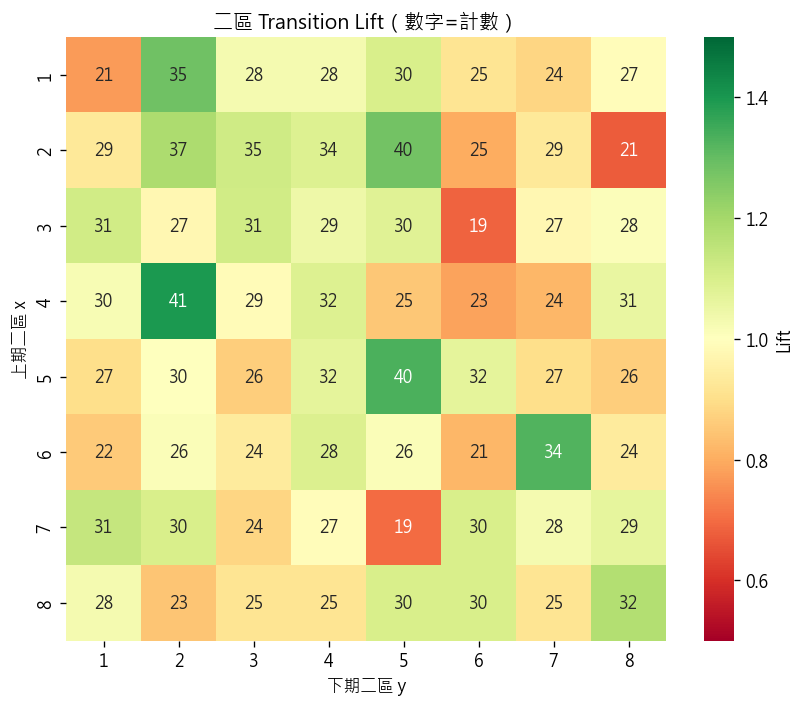

In [8]:
p0_z2 = 1 / 8

# Test B 二區
testB_z2 = []
for x in range(1, 9):
    row = T_z2[x, 1:9]
    row_total = row.sum()
    if row_total == 0:
        continue
    expected = np.full(8, row_total / 8)
    chi2, p = stats.chisquare(row, f_exp=expected)
    testB_z2.append({"x": x, "chi2": chi2, "p": p})
testB_z2_df = pd.DataFrame(testB_z2).set_index("x")

# Test A 二區
testA_z2_records = []
freq_z2_src_arr = np.zeros(9, dtype=int)
for x in draws_z2[:-1]:
    freq_z2_src_arr[x] += 1

for x in range(1, 9):
    n_x = freq_z2_src_arr[x]
    for y in range(1, 9):
        k = T_z2[x, y]
        res = stats.binomtest(k, n=n_x, p=p0_z2, alternative="two-sided")
        testA_z2_records.append({"x": x, "y": y, "k": k, "n": n_x,
                                  "obs_rate": k/n_x, "p_raw": res.pvalue})
testA_z2_df = pd.DataFrame(testA_z2_records)
_, q_z2, _, _ = multipletests(testA_z2_df["p_raw"].values, method="fdr_bh")
testA_z2_df["q_bh"] = q_z2
testA_z2_df["lift"] = testA_z2_df["obs_rate"] / p0_z2
sig_A_z2 = testA_z2_df[testA_z2_df["q_bh"] < 0.05]

print("=== 二區 Test B（8 個號碼）===")
print(testB_z2_df.round(4))
print()
print(f"=== 二區 Test A FDR q<0.05：{len(sig_A_z2)} 個 ===")

# 二區 heatmap
fig, ax = plt.subplots(figsize=(7, 6))
hm = T_z2[1:9, 1:9].astype(float)
expected_cell_z2 = freq_z2_src_arr[1:9].reshape(-1, 1) * p0_z2
lift_z2 = hm / expected_cell_z2
sns.heatmap(lift_z2, annot=T_z2[1:9, 1:9], fmt="d", cmap="RdYlGn",
            center=1.0, vmin=0.5, vmax=1.5,
            xticklabels=range(1,9), yticklabels=range(1,9), ax=ax,
            cbar_kws={"label": "Lift"})
ax.set_title("二區 Transition Lift（數字=計數）")
ax.set_xlabel("下期二區 y")
ax.set_ylabel("上期二區 x")
plt.tight_layout()
plt.show()

## 7. Phase 1 結論

In [9]:
print("=" * 60)
print("Phase 1 Transition Matrix — 結論")
print("=" * 60)

print("\n【一區（1–38）】")
print(f"  Test B（row-level χ²）：")
print(f"    原始 p<0.05：{len(sig_B_raw)} / 38 個（隨機期望 ~{38*0.05:.0f}）")
print(f"    FDR q<0.05：{len(sig_B_fdr)} / 38 個")
print(f"  Test A（cell-level binomial + FDR）：")
print(f"    FDR q<0.05：{len(sig_A)} / {len(testA_df)} 個")

print("\n【二區（1–8）】")
sig_B_z2 = testB_z2_df[testB_z2_df["p"] < 0.05]
print(f"  Test B 原始 p<0.05：{len(sig_B_z2)} / 8 個")
print(f"  Test A FDR q<0.05：{len(sig_A_z2)} / {len(testA_z2_df)} 個")

print()

# 判斷是否有訊號
has_signal_z1 = len(sig_B_fdr) > 0 or len(sig_A) > 0
has_signal_z2 = len(sig_A_z2) > 0

if not has_signal_z1 and not has_signal_z2:
    print("🔴 結論：一區 & 二區均無通過 FDR 校正的顯著跨期關聯訊號。")
    print("   依照預設證偽門檻，lag-1 transition 方向無法支持預測假說。")
    print("   → 建議結案（Phase 4），誠實標註「lag-1 無跨期訊號」。")
elif has_signal_z1 or has_signal_z2:
    print("🟡 結論：發現部分 FDR 顯著訊號，需進入 Phase 2 holdout 回測驗證。")
    if len(sig_A) > 0:
        print(f"   一區顯著 transition：{len(sig_A)} 個 (x,y) pair")
    if len(sig_A_z2) > 0:
        print(f"   二區顯著 transition：{len(sig_A_z2)} 個 (x,y) pair")
    print("   ⚠️  FDR 顯著 ≠ 真實有效，仍需 Phase 2 holdout 作最終確認。")

print()
print("⚠️  Holdout 100 期仍鎖定，未使用任何 holdout 資料。")

Phase 1 Transition Matrix — 結論

【一區（1–38）】
  Test B（row-level χ²）：
    原始 p<0.05：0 / 38 個（隨機期望 ~2）
    FDR q<0.05：0 / 38 個
  Test A（cell-level binomial + FDR）：
    FDR q<0.05：0 / 1444 個

【二區（1–8）】
  Test B 原始 p<0.05：0 / 8 個
  Test A FDR q<0.05：0 / 64 個

🔴 結論：一區 & 二區均無通過 FDR 校正的顯著跨期關聯訊號。
   依照預設證偽門檻，lag-1 transition 方向無法支持預測假說。
   → 建議結案（Phase 4），誠實標註「lag-1 無跨期訊號」。

⚠️  Holdout 100 期仍鎖定，未使用任何 holdout 資料。
